# **Lab 02:** Creating your own CNN with PyTorch

### **General Instructions**

- In this lab, you'll create your own CNN in order to surpass an accuracy of 70% on CIFAR-10.

### **System Diagram Requirement**

You must include a **diagram of your system pipeline** showing the CNN architecture.

This diagram is **required** to understand your model logic.

You can draw it digitally, use any Pyhton library, or by hand and include an image.

If your diagram was created assisted by GenAI, also include the `promt` used in the next block. If the generated system diagram is not clear or you cannot interpret it, adjust the prompt as needed or draw it by hand.

### Prompt:

Genera un diagrama en Python que represente gráficamente la arquitectura completa del modelo, comenzando desde la base de datos hasta la salida final del sistema.

El diagrama debe ser claro y adecuado para explicarlo en clase, mostrando el flujo completo del proceso (pipeline).

Debe incluir explícitamente:

La base de datos (dataset de entrada)

Preprocesamiento de datos

Número de capas convolucionales

Tamaño de los kernels en cada capa

Capas de pooling (si existen)

Capas fully connected (densas)

Funciones de activación

Capa de salida

El resultado debe generarse en Python (usando por ejemplo matplotlib, graphviz o similar) y producir una visualización clara tipo diagrama de arquitectura.

### **Load the CIFAR-10 dataset**

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, ConcatDataset, DataLoader


In [24]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

### **Create your CNN with PyTorch and train it on the CIFAR-10 dataset**

###  Loss Function and Optimizer 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class IntermediateCNN(nn.Module):
    def __init__(self):
        super(IntermediateCNN, self).__init__()
        
        # Capa 1: Extrae características básicas (líneas, bordes)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Capa 2: Extrae texturas y formas simples
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Capa 3: NUEVA CAPA - Nivel de abstracción más alto (partes de objetos)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Clasificador (Capas Densas)
        # La imagen original de 32x32 pasa por tres poolings (reducción a la mitad):
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(p=0.5) 
        self.fc2 = nn.Linear(256, 10) 

    def forward(self, x):
        # Pasamos por las 3 capas convolucionales + ReLU + Pooling
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        
        # Aplanamos el tensor (Flatten)
        x = x.view(x.size(0), -1)
        
        # Pasamos por la capa densa, aplicamos Dropout y sacamos la predicción
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Instanciamos el modelo de forma limpia
model = IntermediateCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [32]:
epochs = 10
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}')


Epoch 1, Loss: 1.4593
Epoch 2, Loss: 1.0520
Epoch 3, Loss: 0.8493
Epoch 4, Loss: 0.7180
Epoch 5, Loss: 0.6111
Epoch 6, Loss: 0.5193
Epoch 7, Loss: 0.4339
Epoch 8, Loss: 0.3606
Epoch 9, Loss: 0.2917
Epoch 10, Loss: 0.2277


### **Evaluate the accuracy of your CNN (must be >= 70%)**

¡Pesos del modelo guardados exitosamente como 'intermediate_cnn_cifar10.pth'!

Resultados Finales en Test:
Loss: 0.8819 | Accuracy: 76.05%


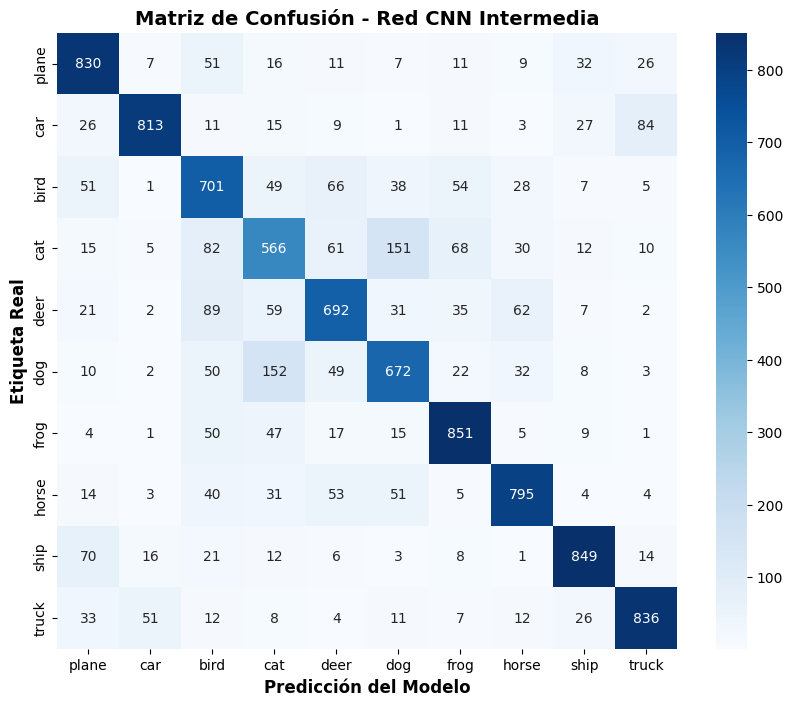

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. GUARDAR EL MODELO ---
# Guardamos los pesos de nuestra nueva red intermedia
torch.save(model.state_dict(), 'intermediate_cnn_cifar10.pth')
print("¡Pesos del modelo guardados exitosamente como 'intermediate_cnn_cifar10.pth'!")

# --- 2. EVALUACIÓN Y MATRIZ DE CONFUSIÓN MANUAL ---
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
num_classes = len(classes)

# Matriz de 10x10 llena de ceros (en la CPU por defecto)
conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int32)

model.eval() # Modo evaluación 
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad(): # Desactivamos gradientes para no consumir VRAM innecesaria
    for data in testloader:
        inputs, labels = data[0].to(device), data[1].to(device)
        
        # Predicciones
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item()
        
        # Obtenemos la clase ganadora
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        # Llenamos la matriz sumando 1 en las coordenadas [Real, Predicción]
        for t, p in zip(labels.view(-1), predicted.view(-1)):
            conf_matrix[t.long(), p.long()] += 1

# --- 3. MÉTRICAS FINALES ---
final_test_loss = test_loss / len(testloader)
final_test_acc = 100 * test_correct / test_total

print(f"\nResultados Finales en Test:")
print(f"Loss: {final_test_loss:.4f} | Accuracy: {final_test_acc:.2f}%")

# --- 4. VISUALIZACIÓN DE LA MATRIZ ---
plt.figure(figsize=(10, 8))
# Pasamos el tensor de PyTorch a NumPy para que Seaborn lo entienda
sns.heatmap(conf_matrix.numpy(), annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusión - Red CNN Intermedia', fontsize=14, fontweight='bold')

# Guardamos el gráfico como imagen por si la necesitas para las diapositivas
plt.savefig('matriz_confusion_cifar10.png', dpi=300, bbox_inches='tight')
plt.show()

### **System Diagram**

Insert your system diagram below (image or drawing). It must clearly show:

- Number of convolutional layers  
- Kernel size(s)
- Pooling layers (if any)  
- etc..  

--- Generando Diagramas ---

1. Diagrama de Pipeline General:
✅ ARCHIVO GUARDADO: 1_Pipeline_General.png


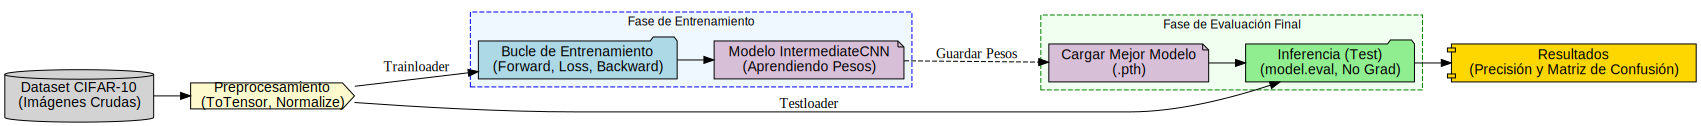

------------------------------

2. Diagrama de Arquitectura CNN:
✅ ARCHIVO GUARDADO: 2_Detalle_CNN_Intermediate.png


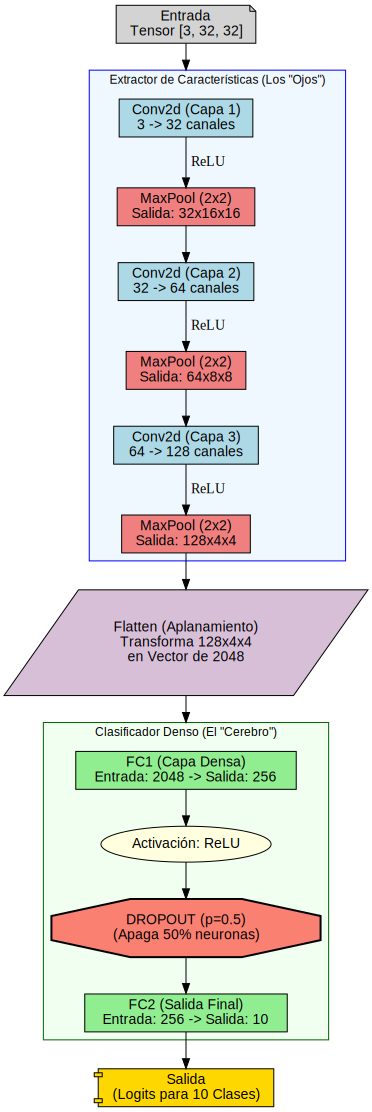

In [1]:
from graphviz import Digraph
import os
from IPython.display import display  # <--- IMPORTANTE: Para mostrar en el notebook

# Aseguramos que el directorio para guardar las imágenes exista
output_dir = 'diagramas_finales_presentacion'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ==========================================
# DIAGRAMA 1: ARQUITECTURA GENERAL (PIPELINE)
# ==========================================
def generar_diagrama_pipeline_general():
    dot = Digraph(comment='Pipeline General ML', format='png')
    dot.attr(rankdir='LR', fontname='Helvetica', fontsize='12', compound='true')
    dot.attr('node', shape='box', style='filled', fontname='Helvetica')

    # Nodos
    dot.node('Data', 'Dataset CIFAR-10\n(Imágenes Crudas)', shape='cylinder', fillcolor='lightgrey')
    dot.node('Prep', 'Preprocesamiento\n(ToTensor, Normalize)', shape='cds', fillcolor='lemonchiffon')
    
    # Agrupamos entrenamiento y modelo
    with dot.subgraph(name='cluster_train') as c:
        c.attr(label='Fase de Entrenamiento', color='blue', bgcolor='aliceblue', style='dashed')
        c.node('Train', 'Bucle de Entrenamiento\n(Forward, Loss, Backward)', shape='folder', fillcolor='lightblue')
        c.node('Model', 'Modelo IntermediateCNN\n(Aprendiendo Pesos)', shape='note', fillcolor='thistle')
        c.edge('Train', 'Model')

    # Agrupamos evaluación
    with dot.subgraph(name='cluster_eval') as c:
        c.attr(label='Fase de Evaluación Final', color='green', bgcolor='honeydew', style='dashed')
        c.node('Load', 'Cargar Mejor Modelo\n(.pth)', shape='note', fillcolor='thistle')
        c.node('Eval', 'Inferencia (Test)\n(model.eval, No Grad)', shape='folder', fillcolor='lightgreen')
        c.edge('Load', 'Eval')

    dot.node('Results', 'Resultados\n(Precisión y Matriz de Confusión)', shape='component', fillcolor='gold')

    # Conexiones
    dot.edge('Data', 'Prep')
    dot.edge('Prep', 'Train', label=' Trainloader')
    dot.edge('Prep', 'Eval', label=' Testloader')
    dot.edge('Model', 'Load', label=' Guardar Pesos', style='dashed')
    dot.edge('Eval', 'Results')

    return dot

# ==========================================
# DIAGRAMA 2: DETALLE INTERNO DE LA CNN
# ==========================================
def generar_diagrama_cnn_detalle():
    dot = Digraph(comment='Detalle IntermediateCNN', format='png')
    dot.attr(rankdir='TB', compound='true', fontname='Helvetica', fontsize='12')
    dot.attr('node', shape='box', style='filled', fontname='Helvetica')

    # 1. Entrada
    dot.node('Input', 'Entrada\nTensor [3, 32, 32]', shape='note', fillcolor='lightgrey')

    # 2. Parte Convolucional (Los "Ojos")
    with dot.subgraph(name='cluster_features') as c:
        c.attr(label='Extractor de Características (Los "Ojos")', color='blue', bgcolor='aliceblue')
        
        # Bloque 1
        c.node('Conv1', 'Conv2d (Capa 1)\n3 -> 32 canales', fillcolor='lightblue')
        c.node('Pool1', 'MaxPool (2x2)\nSalida: 32x16x16', fillcolor='lightcoral')
        c.edge('Conv1', 'Pool1', label=' ReLU')

        # Bloque 2
        c.node('Conv2', 'Conv2d (Capa 2)\n32 -> 64 canales', fillcolor='lightblue')
        c.node('Pool2', 'MaxPool (2x2)\nSalida: 64x8x8', fillcolor='lightcoral')
        c.edge('Conv2', 'Pool2', label=' ReLU')

        # Bloque 3
        c.node('Conv3', 'Conv2d (Capa 3)\n64 -> 128 canales', fillcolor='lightblue')
        c.node('Pool3', 'MaxPool (2x2)\nSalida: 128x4x4', fillcolor='lightcoral')
        c.edge('Conv3', 'Pool3', label=' ReLU')
        
        c.edge('Pool1', 'Conv2')
        c.edge('Pool2', 'Conv3')

    # 3. Transición
    dot.node('Flatten', 'Flatten (Aplanamiento)\nTransforma 128x4x4\nen Vector de 2048', shape='parallelogram', fillcolor='thistle')

    # 4. Clasificador (El "Cerebro")
    with dot.subgraph(name='cluster_classifier') as c:
        c.attr(label='Clasificador Denso (El "Cerebro")', color='darkgreen', bgcolor='honeydew')
        c.node('FC1', 'FC1 (Capa Densa)\nEntrada: 2048 -> Salida: 256', fillcolor='lightgreen')
        c.node('ReLU_FC', 'Activación: ReLU', shape='ellipse', fillcolor='lightyellow')
        c.node('Drop', 'DROPOUT (p=0.5)\n(Apaga 50% neuronas)', shape='octagon', fillcolor='salmon', style='filled,bold')
        c.node('FC2', 'FC2 (Salida Final)\nEntrada: 256 -> Salida: 10', fillcolor='lightgreen')
        
        c.edge('FC1', 'ReLU_FC')
        c.edge('ReLU_FC', 'Drop')
        c.edge('Drop', 'FC2')

    # 5. Salida
    dot.node('Output', 'Salida\n(Logits para 10 Clases)', shape='component', fillcolor='gold')

    # Conexiones principales
    dot.edge('Input', 'Conv1', lhead='cluster_features')
    dot.edge('Pool3', 'Flatten')
    dot.edge('Flatten', 'FC1', lhead='cluster_classifier')
    dot.edge('FC2', 'Output')

    return dot

# ==========================================
# FUNCIÓN HELPER PARA GUARDAR
# ==========================================
def guardar_diagrama(dot, nombre_archivo):
    output_path = os.path.join(output_dir, nombre_archivo)
    try:
        # cleanup=True borra el archivo intermedio de texto (código fuente DOT)
        dot.render(output_path, view=False, cleanup=True)
        print(f"✅ ARCHIVO GUARDADO: {nombre_archivo}.png")
    except Exception as e:
        print(f"⚠️ ERROR: {e}")

# ==========================================
# EJECUCIÓN PRINCIPAL
# ==========================================
if __name__ == '__main__':
    print("--- Generando Diagramas ---")

    # 1. Pipeline General
    print("\n1. Diagrama de Pipeline General:")
    dot_pipeline = generar_diagrama_pipeline_general()
    guardar_diagrama(dot_pipeline, '1_Pipeline_General')
    display(dot_pipeline) # <--- ESTO DIBUJA EL GRÁFICO EN LA CELDA

    print("-" * 30)

    # 2. Detalle CNN
    print("\n2. Diagrama de Arquitectura CNN:")
    dot_cnn = generar_diagrama_cnn_detalle()
    guardar_diagrama(dot_cnn, '2_Detalle_CNN_Intermediate')
    display(dot_cnn)      # <--- ESTO DIBUJA EL GRÁFICO EN LA CELDA

### **Written Analysis Questions**

### 1. Why increasing depth could improve performance.
 Permite aprender características jerárquicas más complejas y abstractas, mejorando la capacidad de representación.

### 2. Under what conditions deeper networks may hurt performance.
Cuando el conjunto de datos es pequeño (overfitting) o cuando surge el problema de desvanecimiento del gradiente.

### 3. How could dropout, batch normalization, or data augmentation help?
Ayudan a regularizar el modelo para reducir el overfitting y, en el caso de Batch Norm, aceleran la convergencia.

### 4. How would you determine whether your CNN is overfitting or underfitting?
Comparando pérdidas: si la de entrenamiento es baja y validación alta es overfitting; si ambas son altas es underfitting.

### 5. Which architectural components most impact computational cost?
Las capas convolucionales consumen la mayor parte del cómputo (FLOPs) y las capas densas consumen más memoria.

### 6. Whether the accuracy gain justifies the added complexity in a real-world deployment scenario.
 Solo se justifica si la mejora en precisión es crítica y el hardware soporta la latencia sin afectar la experiencia.

## **Grading Rubric (10 points)**

| Criterion | Points |
|------------|--------|
| **Baseline Reproduction** – Correct implementation and training of the provided baseline CNN. Clear report of baseline accuracy and training setup. | 1 |
| **Architectural Modifications** – Meaningful and technically justified changes to the CNN architecture (e.g., depth, kernel size, normalization, dropout, residual connections). Changes must go beyond trivial parameter tuning. | 2 |
| **Written Architectural Justification** – Clear explanation of *why* the chosen modifications should improve performance (receptive field, feature hierarchy, regularization, gradient flow, etc.). | 2 |
| **Experimental Design & Comparison** – Systematic comparison between baseline and modified model (same dataset split, controlled variables, reported metrics). Includes training/validation accuracy curves. | 2 |
| **Performance Improvement** – Modified architecture surpasses baseline validation/test accuracy. <br>• +1% improvement: 0.5 pts <br>• +2% improvement: 1 pt | 1 |
| **Generalization Analysis** – Discussion of overfitting/underfitting behavior and the role of regularization techniques (BatchNorm, Dropout, data augmentation, etc.). | 1 |
| **Computational Tradeoff Reflection** – Analysis of parameter count, training time, and whether the accuracy gain justifies the added complexity. | 1 |
| **Code Clarity & PyTorch Best Practices** – Clean modular implementation (proper use of `nn.Module`, readable forward pass, reproducibility practices). | 1 |
| **Total** | **10** |

---

### Notes

- Simply increasing the number of filters without justification will not receive full architectural credit.
- Accuracy alone does not guarantee a high grade — reasoning and analysis are weighted heavily.
- Extra credit (+0.5) may be awarded for implementing advanced concepts (e.g., residual blocks, learning rate scheduling experiments, or ablation studies). Applies just for students with <10 points.

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ComplexCNN(nn.Module):
    def __init__(self):
        super(ComplexCNN, self).__init__()
        
        # --- BLOQUE CONVOLUCIONAL 1 ---
        # Aumentamos a 32 filtros. Usamos Batch Normalization después de cada convolución.
        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1a = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(p=0.2) # Apagamos el 20% de las neuronas
        
        # --- BLOQUE CONVOLUCIONAL 2 ---
        # Aumentamos la profundidad a 64 filtros
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(p=0.3) # Apagamos el 30%
        
        # --- BLOQUE CONVOLUCIONAL 3 ---
        # Aumentamos a 128 filtros para capturar patrones muy complejos
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop3 = nn.Dropout2d(p=0.4) # Apagamos el 40%
        
        # --- CLASIFICADOR (CAPAS DENSAS) ---
        # Después de 3 MaxPools (reducciones a la mitad), la imagen pasa de 32x32 -> 16x16 -> 8x8 -> 4x4
        # Tensor aplanado: 128 canales * 4 * 4 = 2048 características
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.drop_fc = nn.Dropout(p=0.5) # Apagamos el 50% en la capa densa
        self.fc2 = nn.Linear(512, 10) # 10 clases de salida

    def forward(self, x):
        # Pasada por el Bloque 1
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.drop1(self.pool1(x))
        
        # Pasada por el Bloque 2
        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.drop2(self.pool2(x))
        
        # Pasada por el Bloque 3
        x = F.relu(self.bn3a(self.conv3a(x)))
        x = F.relu(self.bn3b(self.conv3b(x)))
        x = self.drop3(self.pool3(x))
        
        # Aplanamiento (Flatten)
        x = x.view(-1, 128 * 4 * 4)
        
        # Pasada por el Clasificador
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.drop_fc(x)
        x = self.fc2(x) # La salida no lleva activación, eso lo hace CrossEntropyLoss
        
        return x

# Instanciamos el nuevo modelo
model = ComplexCNN().to(device)
print(model) # Esto imprimirá la arquitectura completa en tu consola

ComplexCNN(
  (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout2d(p=0.2, inplace=False)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout2d(p=0.3, inplace=False)
  (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 

In [20]:
# 1. Definir la función de pérdida y el optimizador para el nuevo modelo
criterion = nn.CrossEntropyLoss()
# Usamos un learning rate estándar para Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15 # Le damos unas cuantas épocas más porque la red es más profunda

print("Iniciando el entrenamiento de la red profunda...")
for epoch in range(epochs):
    
    # ==========================================
    #               ENTRENAMIENTO
    # ==========================================
    model.train() # Activa el Dropout y la normalización por lotes
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in trainloader:
        # Enviar datos a la tarjeta gráfica
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass (calcular gradientes y actualizar pesos)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct_train / total_train
    
    # ==========================================
    #                 EVALUACIÓN (TEST)
    # ==========================================
    model.eval() # Desactiva el Dropout. Fija los pesos para evaluar.
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    # No calculamos gradientes aquí, ahorra mucha memoria y tiempo
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    final_test_loss = test_loss / len(testloader)
    final_test_acc = 100 * correct_test / total_test
    
    # ==========================================
    #            IMPRIMIR RESULTADOS
    # ==========================================
    print(f"Época [{epoch + 1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {final_test_loss:.4f} - Test Acc: {final_test_acc:.2f}%")

print("\n¡Entrenamiento finalizado!")

Iniciando el entrenamiento de la red profunda...
Época [1/15] | Train Loss: 1.5558 - Train Acc: 43.41% | Test Loss: 1.0775 - Test Acc: 61.36%
Época [2/15] | Train Loss: 1.1696 - Train Acc: 58.55% | Test Loss: 0.8691 - Test Acc: 69.64%
Época [3/15] | Train Loss: 1.0176 - Train Acc: 64.00% | Test Loss: 0.7879 - Test Acc: 72.01%
Época [4/15] | Train Loss: 0.9268 - Train Acc: 67.53% | Test Loss: 0.7228 - Test Acc: 74.84%
Época [5/15] | Train Loss: 0.8615 - Train Acc: 69.88% | Test Loss: 0.6860 - Test Acc: 75.98%
Época [6/15] | Train Loss: 0.7998 - Train Acc: 72.02% | Test Loss: 0.6428 - Test Acc: 77.23%
Época [7/15] | Train Loss: 0.7544 - Train Acc: 73.68% | Test Loss: 0.6231 - Test Acc: 78.04%
Época [8/15] | Train Loss: 0.7169 - Train Acc: 75.18% | Test Loss: 0.5973 - Test Acc: 79.06%
Época [9/15] | Train Loss: 0.6764 - Train Acc: 76.46% | Test Loss: 0.5619 - Test Acc: 80.44%
Época [10/15] | Train Loss: 0.6557 - Train Acc: 77.34% | Test Loss: 0.5460 - Test Acc: 80.92%
Época [11/15] | Trai